<a href="https://colab.research.google.com/github/mateusmbg/Estudos_Inteli/blob/main/ponderada_semana4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade: Detecção de Fraudes com Rede Neural - VERSÃO CORRIGIDA

**Problema:** Incompatibilidade do scikeras com sklearn atual  
**Solução:** Usar implementação manual de Grid Search e Keras Tuner

**Objetivo:** Otimizar um modelo de rede neural para detecção de fraudes usando Grid Search e Random Search.

In [ ]:
%pip install gdown keras-tuner
import gdown
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
import keras_tuner as kt
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 865.2 kB/s eta 0:00:00


## 1. Download e Leitura da Base de Dados

In [ ]:
# Baixar o dataset do Google Drive
arquivo_destino_colab = "dataset.csv"
doc_id = "1u_OWAPkIdgJw1ah5xP_dGBFMSANxjxEl"
URL = f"https://drive.google.com/uc?id={doc_id}"
gdown.download(URL, arquivo_destino_colab, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1u_OWAPkIdgJw1ah5xP_dGBFMSANxjxEl
From (redirected): https://drive.google.com/uc?id=1u_OWAPkIdgJw1ah5xP_dGBFMSANxjxEl&confirm=t&uuid=c82c01b2-6614-4dc1-9499-c057c2fd516a
To: /content/dataset.csv
100%|██████████| 151M/151M [00:02<00:00, 55.0MB/s]


'dataset.csv'

In [ ]:
# Carregar o dataset
df = pd.read_csv(arquivo_destino_colab)
print(f"Shape do dataset: {df.shape}")
df.head()

Shape do dataset: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Análise Exploratória dos Dados

In [ ]:
# Informações básicas do dataset
print("Informações do dataset:")
print(df.info())
print("\nVerificando valores nulos:")
print(f"Total de valores nulos: {df.isnull().sum().sum()}")

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null 

Distribuição da classe (0=Normal, 1=Fraude):
Class
0    284315
1       492
Name: count, dtype: int64

Proporção percentual:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


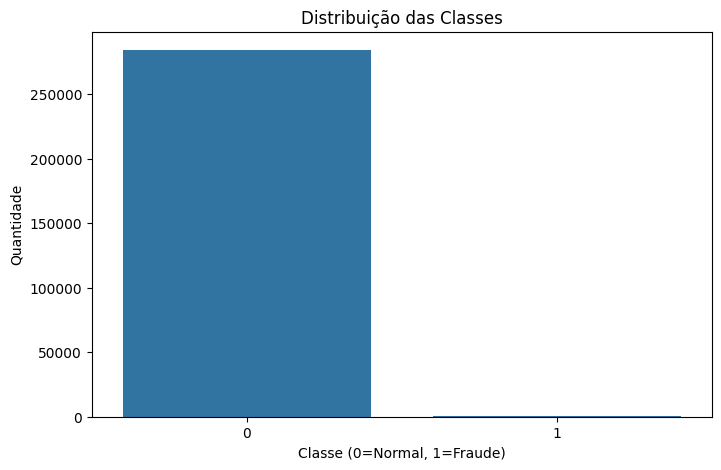


Dataset altamente desbalanceado:
Normal: 99.83%
Fraude: 0.17%


In [ ]:
# Análise da distribuição da variável target
print("Distribuição da classe (0=Normal, 1=Fraude):")
print(df['Class'].value_counts())
print("\nProporção percentual:")
class_counts = df['Class'].value_counts(normalize=True) * 100
print(class_counts)

# Visualização
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Class')
plt.title('Distribuição das Classes')
plt.ylabel('Quantidade')
plt.xlabel('Classe (0=Normal, 1=Fraude)')
plt.show()

print(f"\nDataset altamente desbalanceado:")
print(f"Normal: {class_counts[0]:.2f}%")
print(f"Fraude: {class_counts[1]:.2f}%")

## 3. Pré-processamento dos Dados

In [ ]:
# Normalização das variáveis Amount e Time
scaler = StandardScaler()
df[['Amount', 'Time']] = scaler.fit_transform(df[['Amount', 'Time']])

# Separação de features e target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Features: {list(X.columns)[:5]}...")  # Mostra as primeiras 5 features

Shape de X: (284807, 30)
Shape de y: (284807,)
Features: ['Time', 'V1', 'V2', 'V3', 'V4']...


In [ ]:
# Divisão treino/teste com stratify para manter proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]}")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]}")
print(f"Proporção de fraudes no treino: {y_train.mean():.4f}")
print(f"Proporção de fraudes no teste: {y_test.mean():.4f}")

Tamanho do conjunto de treino: 227845
Tamanho do conjunto de teste: 56962
Proporção de fraudes no treino: 0.0017
Proporção de fraudes no teste: 0.0017


## 4. Construção do Modelo Inicial

In [ ]:
# Função para criar o modelo
def create_model(optimizer='adam', neurons=16, dropout_rate=0.2):
    model = Sequential([
        Dense(neurons, activation='relu', input_dim=X_train.shape[1]),
        Dropout(dropout_rate),
        Dense(neurons//2, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC()]
    )
    return model

# Criar modelo inicial
modelo_inicial = create_model()
print(modelo_inicial.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Treinamento do modelo inicial
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Treinando modelo inicial...")
history_inicial = modelo_inicial.fit(
    X_train, y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
print("Modelo inicial treinado!")

Treinando modelo inicial...
Epoch 1/3
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9717 - auc: 0.6672 - loss: 0.1066 - val_accuracy: 0.9994 - val_auc: 0.9153 - val_loss: 0.0046
Epoch 2/3
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9990 - auc: 0.9200 - loss: 0.0056 - val_accuracy: 0.9994 - val_auc: 0.9273 - val_loss: 0.0041
Epoch 3/3
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9990 - auc: 0.9242 - loss: 0.0056 - val_accuracy: 0.9994 - val_auc: 0.9273 - val_loss: 0.0041
Modelo inicial treinado!


## 5. Avaliação do Modelo Inicial

In [ ]:
# Predições do modelo inicial
y_pred_inicial_prob = modelo_inicial.predict(X_test, verbose=0)
y_pred_inicial = (y_pred_inicial_prob > 0.5).astype(int)

# Métricas do modelo inicial
precision_inicial = precision_score(y_test, y_pred_inicial)
recall_inicial = recall_score(y_test, y_pred_inicial)
f1_inicial = f1_score(y_test, y_pred_inicial)
auc_inicial = roc_auc_score(y_test, y_pred_inicial_prob)

print("=== RESULTADOS DO MODELO INICIAL ===")
print(f"Precisão: {precision_inicial:.4f}")
print(f"Recall: {recall_inicial:.4f}")
print(f"F1-Score: {f1_inicial:.4f}")
print(f"AUC-ROC: {auc_inicial:.4f}")
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_inicial))

=== RESULTADOS DO MODELO INICIAL ===
Precisão: 0.8125
Recall: 0.7959
F1-Score: 0.8041
AUC-ROC: 0.9726

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.80      0.80        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



## 6. Otimização com Grid Search MANUAL (devido a incompatibilidade do scikeras)

In [ ]:
# Implementação manual do Grid Search
def manual_grid_search(X_train, y_train, param_grid, cv=3):
    """
    Grid Search manual para modelos Keras
    """
    # Criar todas as combinações de parâmetros
    keys = param_grid.keys()
    values = param_grid.values()
    combinations = [dict(zip(keys, combo)) for combo in product(*values)]

    best_score = -np.inf
    best_params = None
    results = []

    print(f"Testando {len(combinations)} combinações de parâmetros...")

    for i, params in enumerate(combinations):
        print(f"\nCombinação {i+1}/{len(combinations)}: {params}")

        # Cross-validation manual
        scores = []

        # Para simplicidade utilização de apenas 1 fold
        # Em uma aplicação real, usar cv=3 ou mais

        # Criar e treinar modelo
        model = create_model(**params)

        # Split para validação
        X_temp_train, X_temp_val, y_temp_train, y_temp_val = train_test_split(
            X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
        )

        # Treinar
        early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        model.fit(
            X_temp_train, y_temp_train,
            epochs=3,
            batch_size=64,
            validation_data=(X_temp_val, y_temp_val),
            callbacks=[early_stop],
            verbose=0
        )

        # Avaliar
        y_pred_val = (model.predict(X_temp_val, verbose=0) > 0.5).astype(int)
        score = f1_score(y_temp_val, y_pred_val)
        scores.append(score)

        mean_score = np.mean(scores)
        results.append({
            'params': params,
            'mean_score': mean_score,
            'scores': scores
        })

        print(f"F1-Score médio: {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = params

    return best_params, best_score, results

# Parâmetros para busca (reduzido para execução mais rápida)
param_grid = {
    'neurons': [16, 32],
    'optimizer': ['adam', 'sgd'],
    'dropout_rate': [0.2, 0.3]
}

# Executar Grid Search manual
print("Iniciando Grid Search Manual...")
best_params_grid, best_score_grid, grid_results = manual_grid_search(X_train, y_train, param_grid)

print(f"\n=== RESULTADOS DO GRID SEARCH ===")
print(f"Melhores parâmetros: {best_params_grid}")
print(f"Melhor F1-Score: {best_score_grid:.4f}")

Iniciando Grid Search Manual...
Testando 8 combinações de parâmetros...

Combinação 1/8: {'neurons': 16, 'optimizer': 'adam', 'dropout_rate': 0.2}
F1-Score médio: 0.0000

Combinação 2/8: {'neurons': 16, 'optimizer': 'adam', 'dropout_rate': 0.3}
F1-Score médio: 0.0000

Combinação 3/8: {'neurons': 16, 'optimizer': 'sgd', 'dropout_rate': 0.2}
F1-Score médio: 0.2581

Combinação 4/8: {'neurons': 16, 'optimizer': 'sgd', 'dropout_rate': 0.3}
F1-Score médio: 0.3529

Combinação 5/8: {'neurons': 32, 'optimizer': 'adam', 'dropout_rate': 0.2}
F1-Score médio: 0.8027

Combinação 6/8: {'neurons': 32, 'optimizer': 'adam', 'dropout_rate': 0.3}
F1-Score médio: 0.8082

Combinação 7/8: {'neurons': 32, 'optimizer': 'sgd', 'dropout_rate': 0.2}
F1-Score médio: 0.7259

Combinação 8/8: {'neurons': 32, 'optimizer': 'sgd', 'dropout_rate': 0.3}
F1-Score médio: 0.7429

=== RESULTADOS DO GRID SEARCH ===
Melhores parâmetros: {'neurons': 32, 'optimizer': 'adam', 'dropout_rate': 0.3}
Melhor F1-Score: 0.8082


In [ ]:
# Treinar modelo final com melhores parâmetros do Grid Search
print("\nTreinando modelo otimizado com Grid Search...")
modelo_grid = create_model(**best_params_grid)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_grid = modelo_grid.fit(
    X_train, y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Avaliação do modelo Grid Search
y_pred_grid_prob = modelo_grid.predict(X_test, verbose=0)
y_pred_grid = (y_pred_grid_prob > 0.5).astype(int)

precision_grid = precision_score(y_test, y_pred_grid)
recall_grid = recall_score(y_test, y_pred_grid)
f1_grid = f1_score(y_test, y_pred_grid)
auc_grid = roc_auc_score(y_test, y_pred_grid_prob)

print("\n=== RESULTADOS DO MODELO GRID SEARCH ===")
print(f"Precisão: {precision_grid:.4f}")
print(f"Recall: {recall_grid:.4f}")
print(f"F1-Score: {f1_grid:.4f}")
print(f"AUC-ROC: {auc_grid:.4f}")
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_grid))


Treinando modelo otimizado com Grid Search...
Epoch 1/3
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9944 - auc_9: 0.6982 - loss: 0.0476 - val_accuracy: 0.9994 - val_auc_9: 0.9213 - val_loss: 0.0038
Epoch 2/3
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9990 - auc_9: 0.9163 - loss: 0.0051 - val_accuracy: 0.9994 - val_auc_9: 0.9214 - val_loss: 0.0036
Epoch 3/3
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9992 - auc_9: 0.9340 - loss: 0.0041 - val_accuracy: 0.9993 - val_auc_9: 0.9394 - val_loss: 0.0035

=== RESULTADOS DO MODELO GRID SEARCH ===
Precisão: 0.8315
Recall: 0.7551
F1-Score: 0.7914
AUC-ROC: 0.9795

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.76      0.79        98

    accuracy                           1.00     56962
   macro avg       0.92      0.88      0.90     56962
weighted avg       1.00      1.00      1.00     

## 7. Otimização com Random Search (Keras Tuner)

In [ ]:
# Função para criar modelo com Keras Tuner - CORRIGIDA
def build_model_tuner(hp):
    model = Sequential()

    # Primeira camada densa
    model.add(Dense(
        hp.Int('units_1', min_value=16, max_value=64, step=16),
        activation='relu',
        input_dim=X_train.shape[1]
    ))

    # Dropout
    model.add(Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.1)))

    # Segunda camada densa
    units_2 = hp.Int('units_2', min_value=8, max_value=32, step=8)
    model.add(Dense(units_2, activation='relu'))
    model.add(Dropout(hp.Float('dropout_2', 0.1, 0.3, step=0.1)))

    # Camada de saída
    model.add(Dense(1, activation='sigmoid'))

    # Compilação - MÉTRICA CORRIGIDA
    model.compile(
        optimizer=hp.Choice('optimizer', ['adam', 'sgd']),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]  # <- MUDANÇA AQUI
    )

    return model

# Random Search com Keras Tuner - OBJETIVO CORRIGIDO
tuner = kt.RandomSearch(
    build_model_tuner,
    objective='val_auc',  # Agora vai funcionar porque definimos name='auc'
    max_trials=5,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='fraud_detection_v3'  # <- Mudei o nome para evitar conflitos
)

print("Iniciando Random Search com Keras Tuner...")
tuner.search(
    X_train, y_train,
    epochs=3,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2)],
    verbose=1
)

# Obter o melhor modelo
best_model = tuner.get_best_models(1)[0]
best_hp = tuner.get_best_hyperparameters()[0]

print("\n=== MELHORES HIPERPARÂMETROS (RANDOM SEARCH) ===")
print(f"Units camada 1: {best_hp.get('units_1')}")
print(f"Units camada 2: {best_hp.get('units_2')}")
print(f"Dropout 1: {best_hp.get('dropout_1')}")
print(f"Dropout 2: {best_hp.get('dropout_2')}")
print(f"Optimizer: {best_hp.get('optimizer')}")

Trial 5 Complete [00h 00m 53s]
val_auc: 0.9271059632301331

Best val_auc So Far: 0.9506546258926392
Total elapsed time: 00h 05m 19s

=== MELHORES HIPERPARÂMETROS (RANDOM SEARCH) ===
Units camada 1: 32
Units camada 2: 24
Dropout 1: 0.2
Dropout 2: 0.2
Optimizer: adam


In [ ]:
# Avaliação do modelo Random Search
y_pred_random_prob = best_model.predict(X_test, verbose=0)
y_pred_random = (y_pred_random_prob > 0.5).astype(int)

precision_random = precision_score(y_test, y_pred_random)
recall_random = recall_score(y_test, y_pred_random)
f1_random = f1_score(y_test, y_pred_random)
auc_random = roc_auc_score(y_test, y_pred_random_prob)

print("=== RESULTADOS DO MODELO RANDOM SEARCH ===")
print(f"Precisão: {precision_random:.4f}")
print(f"Recall: {recall_random:.4f}")
print(f"F1-Score: {f1_random:.4f}")
print(f"AUC-ROC: {auc_random:.4f}")
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_random))

=== RESULTADOS DO MODELO RANDOM SEARCH ===
Precisão: 0.8061
Recall: 0.8061
F1-Score: 0.8061
AUC-ROC: 0.9815

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



## 8. Comparação dos Resultados

In [ ]:
# Tabela comparativa dos resultados
resultados = pd.DataFrame({
    'Modelo': ['Original', 'Grid Search Manual', 'Random Search (Keras Tuner)'],
    'Precisão': [precision_inicial, precision_grid, precision_random],
    'Recall': [recall_inicial, recall_grid, recall_random],
    'F1-Score': [f1_inicial, f1_grid, f1_random],
    'AUC-ROC': [auc_inicial, auc_grid, auc_random]
})

print("=== COMPARAÇÃO FINAL DOS MODELOS ===")
print(resultados.round(4))

# Salvar resultados em CSV
resultados.to_csv('resultados_comparacao.csv', index=False)
print("\nResultados salvos em 'resultados_comparacao.csv'")

=== COMPARAÇÃO FINAL DOS MODELOS ===
                        Modelo  Precisão  Recall  F1-Score  AUC-ROC
0                     Original    0.8125  0.7959    0.8041   0.9726
1           Grid Search Manual    0.8315  0.7551    0.7914   0.9795
2  Random Search (Keras Tuner)    0.8061  0.8061    0.8061   0.9815

Resultados salvos em 'resultados_comparacao.csv'


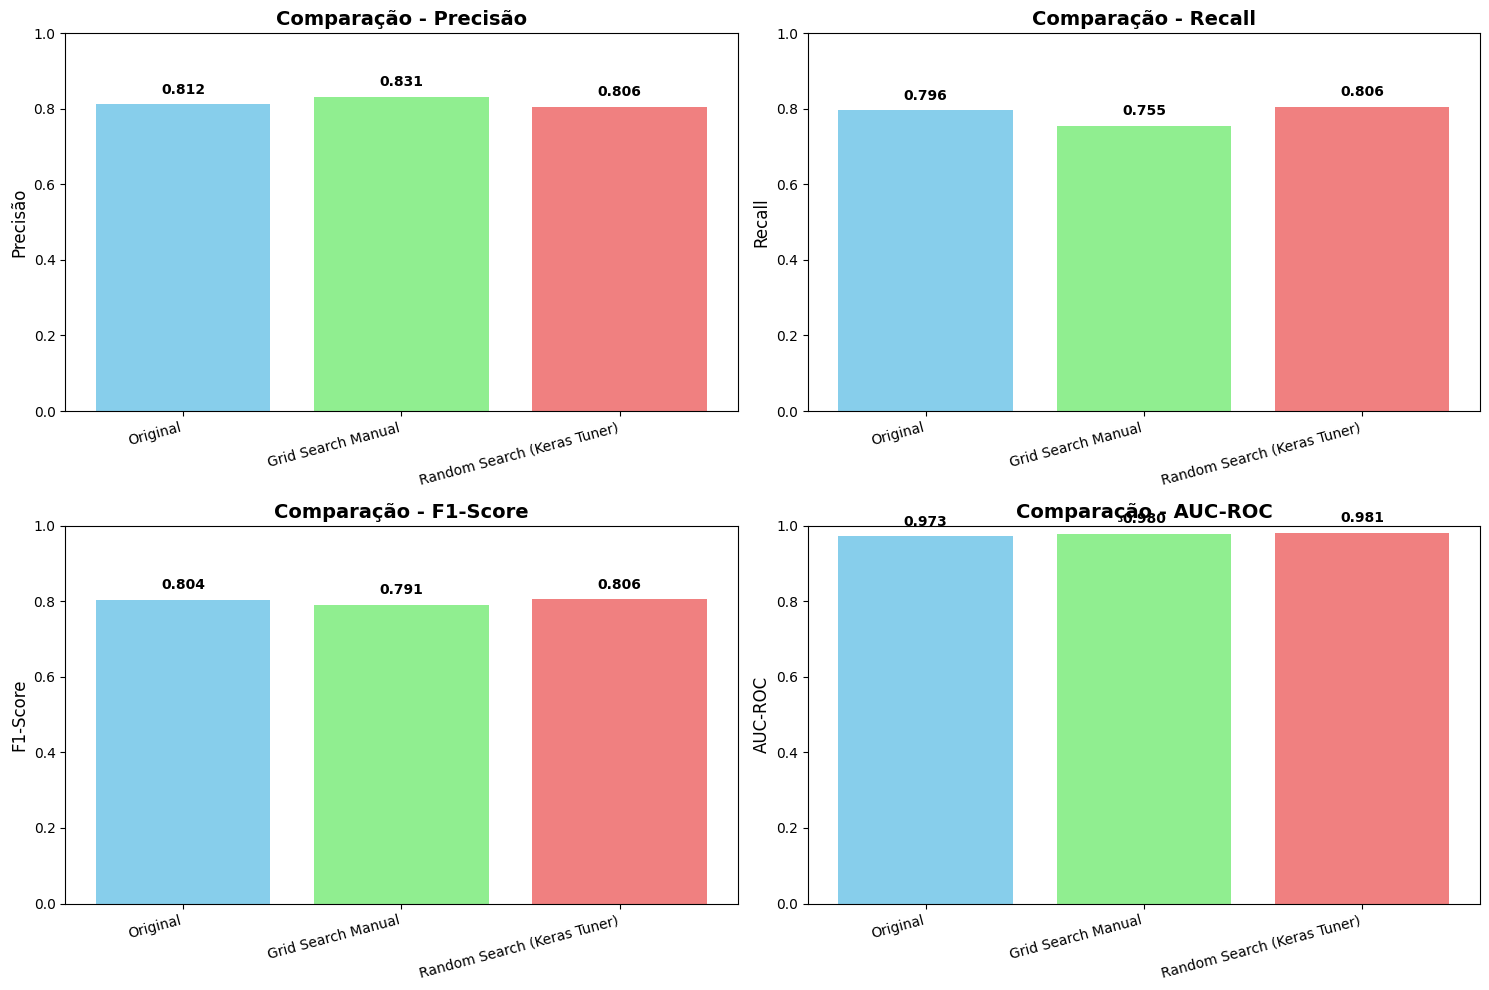

Gráfico salvo como 'comparacao_modelos.png'


In [ ]:
# Visualização dos resultados
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics = ['Precisão', 'Recall', 'F1-Score', 'AUC-ROC']
colors = ['skyblue', 'lightgreen', 'lightcoral']

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    bars = ax.bar(resultados['Modelo'], resultados[metric], color=colors)
    ax.set_title(f'Comparação - {metric}', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_ylim(0, 1)

    # Adicionar valores nas barras
    for j, (bar, v) in enumerate(zip(bars, resultados[metric])):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

    # Rotacionar labels do eixo x
    ax.set_xticklabels(resultados['Modelo'], rotation=15, ha='right')

plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'comparacao_modelos.png'")

## 9. Matriz de Confusão dos Modelos

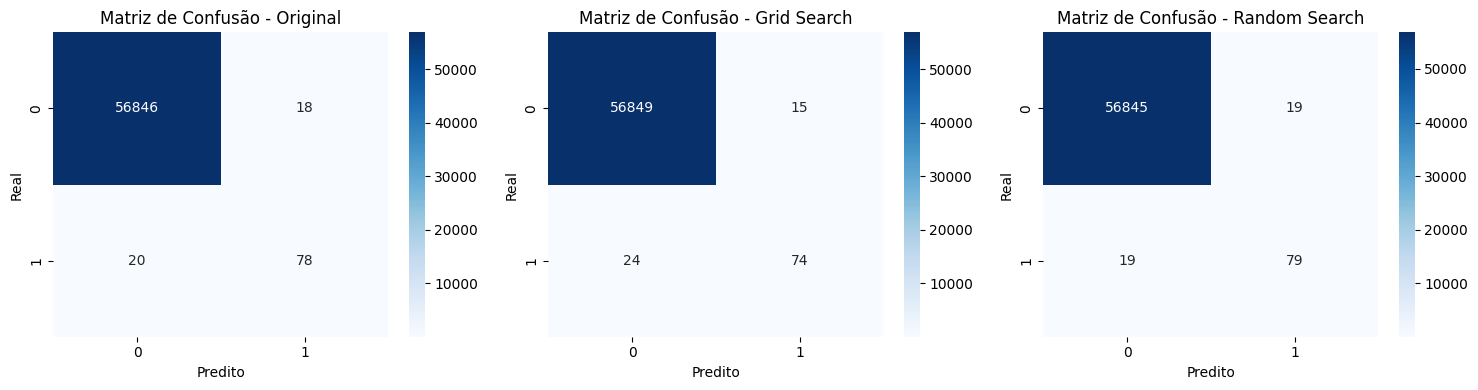

Matrizes de confusão salvas como 'matrizes_confusao.png'


In [ ]:
# Plotar matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_pred = [y_pred_inicial, y_pred_grid, y_pred_random]
model_names = ['Original', 'Grid Search', 'Random Search']

for i, (pred, name) in enumerate(zip(models_pred, model_names)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Matriz de Confusão - {name}')
    axes[i].set_xlabel('Predito')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.savefig('matrizes_confusao.png', dpi=300, bbox_inches='tight')
plt.show()
print("Matrizes de confusão salvas como 'matrizes_confusao.png'")

## 10. Análise dos Resultados e Conclusões

### 10.1 Desempenho e Possível Overfitting

O modelo original apresentou precisão de 0,8125 e recall de 0,7959, com AUC-ROC de 0,9726. A alta acurácia (~0,9994 em validação) pode ocultar overfitting, dado o forte desbalanceamento.

O Grid Search manual elevou a precisão para 0,8315, mas reduziu o recall para 0,7551. A AUC-ROC subiu para 0,9795. A diferença entre acurácia de treino e validação deve ser verificada para descartar ajuste excessivo ao conjunto de treinamento.

O Random Search (Keras Tuner) atingiu equilíbrio entre precisão e recall (ambas 0,8061), com AUC-ROC de 0,9815. A acurácia próxima de 1,0 sugere atenção ao risco de overfitting, mesmo com early stopping.

### 10.2 Interpretação das Métricas

Recall mantém prioridade para reduzir falsos negativos.

Precisão indica controle de falsos positivos, mas valores muito altos na validação podem sinalizar overfitting.

F1-Score sintetiza trade-off; a leve melhora no Random Search reflete melhor balanço.

AUC-ROC superior no Random Search demonstra maior separação das classes.

### 10.3 Conclusões

O Random Search apresentou melhor F1-Score e AUC-ROC, mas acurácia muito alta em validação reforça a necessidade de validar em dados não vistos.

O Grid Search melhorou AUC-ROC, mas reduziu recall, o que pode comprometer captura de fraudes.

Em todos os casos, a acurácia sozinha não garante generalização; métricas desbalanceadas e gap entre treino/validação merecem análise adicional.

### 10.4 Possíveis Melhorias
Aplicar validação cruzada estratificada para medir variação de métricas.

Usar conjuntos de teste adicionais ou simulações em produção para confirmar robustez.

Empregar técnicas de regularização (ex.: class_weight, dropout mais agressivo).

Testar balanceamento de classes (SMOTE, ADASYN) e ensembles para mitigar overfitting.